In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Etapa 1 — Importação de bibliotecas
Nesta etapa, importamos as bibliotecas usadas em todo o notebook:
- `pandas` para leitura e manipulação de dados tabulares;
- `numpy` para cálculos estatísticos (média, quartis, desvio etc.);
- `matplotlib` para visualização gráfica.

Pesquisaremos Homicídios dolosos
1. Saber se existe BPM com muitos registros de homicídios dolosos
2. Verfificar se há um amédia de homicídios dolosos através dos BPM's
3. Fazer uma visualização dos casos que estejam muito acima dos demais
4. Caso não haja muito acima dos demais, mostrar ranking de todos os BPM's
5. Mostrar métricas que sustentem que a média seja uma medida confiável

## Etapa 2 — Carregamento e integração das bases
Aqui carregamos as duas bases CSV e, em seguida, fazemos o `merge` para combinar ocorrências com a tabela de BPMs.
O objetivo é enriquecer as ocorrências com o nome do batalhão correspondente (`NM_BPM`).
Também verificamos a estrutura resultante e ajustamos tipos quando necessário.

In [12]:
try:
    df_ocorrencias = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding="iso-8859-1")
    df_bpm= pd.read_csv('08.BPM.csv', sep=';', encoding="utf-8")

    # print(df_ocorrencias.info())
    # print(df_bpm.info())
    # merge: 
    # left_on -> qual coluna da tabela da esquerda vai ser o indice para para juntar com a da direita
    # right_on -> qual coluna da tabela da direita vai ser o indice para para juntar com a da esquerda
    # how -> modo como seerrá feita a conversão das duas colunas
    # how = right -> pega tudo da direita e copia o que tem combinação da esquerda
    # how = left -> pega tudo da esquerda e copia o que tem combinação da direita
    # how = inner -> pega apenas os registros que possuem combinação em ambas as tabelas
    # how = outer -> pega todos os registros de ambas as tabelas, preenchendo com NaN onde não houver correspondência

    df_merge = df_ocorrencias.merge(df_bpm, left_on='aisp', right_on='COD_BPM', how='left')

    # fillna -> preenche as lacunas deixadas por inconsistência de junção na base de dados
    # será necessário 

    df_merge['COD_BPM'] = df_merge['COD_BPM'].astype(str)
    df_merge.info()
    # df_merge.fillna('BPM não encontrada', inplace=True)

except Exception as e:
    print(f"Ocorreu um erro ao importar dados: {e}")


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        34848 non-null  int64  
 1   mes                         34848 non-null  int64  
 2   ano                         34848 non-null  int64  
 3   mes_ano                     34848 non-null  str    
 4   aisp                        34848 non-null  int64  
 5   risp                        34848 non-null  int64  
 6   munic                       34848 non-null  str    
 7   mcirc                       34848 non-null  int64  
 8   regiao                      34848 non-null  str    
 9   hom_doloso                  34848 non-null  int64  
 10  lesao_corp_morte            34848 non-null  int64  
 11  latrocinio                  34848 non-null  int64  
 12  cvli                        34848 non-null  int64  
 13  hom_por_interv_policial     34848 non-null

## Etapa 3 — Seleção e agregação dos dados
Selecionamos apenas as colunas necessárias (`aisp`, `NM_BPM`, `hom_doloso`) e tratamos valores ausentes.
Depois, agregamos por BPM para obter o total de homicídios dolosos por batalhão.
Esse resumo é a base para as análises estatísticas e visuais.

In [14]:
# filtrar df para respónder as questões
df_doloso = df_merge[['aisp', 'NM_BPM', 'hom_doloso']]
# fillna -> preenche as lacunas deixadas por inconsistência de junção na base de dados
df_doloso.fillna('BPM não encontrada', inplace=True)
df_doloso_agrupado = df_doloso.groupby(['aisp', 'NM_BPM']).sum().reset_index()
print(df_doloso_agrupado)

    aisp              NM_BPM  hom_doloso
0      1  BPM não encontrada         634
1      2              2º BPM         343
2      3              3º BPM        2624
3      4              4º BPM         780
4      5              5º BPM         723
5      6              6º BPM         794
6      7              7º BPM        7087
7      8              8º BPM        4495
8      9              9º BPM        5889
9     10             10º BPM        1082
10    11             11º BPM         953
11    12             12º BPM        3444
12    13  BPM não encontrada         108
13    14             14º BPM        4605
14    15             15º BPM        8474
15    16             16º BPM        2167
16    17             17º BPM         806
17    18             18º BPM        2184
18    19             19º BPM         193
19    20             20º BPM       10696
20    21             21º BPM        3278
21    22             22º BPM        1922
22    23             23º BPM         420
23    24        

## Etapa 4 — Medidas estatísticas iniciais
Transformamos a coluna de homicídios em um array NumPy para calcular:
- quartis ($Q_1$, $Q_2$, $Q_3$);
- média e desvio padrão;
- coeficiente de variação;
- razão média/mediana (delta).
Essas métricas ajudam a entender a dispersão e a confiabilidade da média.

In [15]:
# Calcular média de homicídios dolosos
# Copiar a coluna de homicidios dolosos para um array para ser usado no numpy
doloso_array = np.array(df_doloso_agrupado['hom_doloso'])

q1 = np.quantile(doloso_array, 0.25)
q2 = np.quantile(doloso_array, 0.5)
q3 = np.quantile(doloso_array, 0.75)

media = np.mean(doloso_array)
desvio = np.std(doloso_array)
cv = desvio/media
delta = media/q2


## Etapa 5 — Detecção de outliers e preparação do ranking
Calculamos o IQR e os limites inferior/superior para identificar BPMs com valores muito acima do padrão.
Se houver outliers superiores, o gráfico exibirá apenas esses BPMs;
caso contrário, mostramos o ranking completo ordenado por homicídios dolosos.

In [20]:
# antes de criar um gráfico vamos calcular os outliers
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
# focando na pergunta que foi feita, embora façam-se todos os calculos vamos usar apenas os outliers superiores
df_dolosos_outliers_sup = df_doloso_agrupado[df_doloso_agrupado['hom_doloso'] > limite_superior]
# sem que se fizesse o print, como preparar para fazer um gráfico que mostre ou os outliers ou o ranking 
# sem utilizar dois códigos, otimizando esse processo?
# Para isto vamos verificar um array de saida
df_grafico = None
if df_dolosos_outliers_sup.empty:
    df_grafico = df_doloso_agrupado.sort_values(by='hom_doloso', ascending=False)
    print(f'1.Não há BPMs com número de homicídios dolosos muito maior que outros')
else:
    df_grafico = df_dolosos_outliers_sup
    print(f'2.Há {df_dolosos_outliers_sup.shape[0]} BPMs com alto número de homicídios dolosos')


2.Há 2 BPMs com alto número de homicídios dolosos


## Etapa 6 — Interpretação estatística e visualização
Exibimos as métricas finais (média, mediana, delta, desvio, CV) para avaliar a confiabilidade da média.
Por fim, geramos o gráfico de barras com os BPMs selecionados para análise visual.
Essa etapa facilita a identificação de concentrações ou padrões fora da curva.

2. Média: 2496.10
5. Mediana: 2175.50
5. Delta Media/Mediana: 1.15
5. Desvio padrão: 2373.29
5. Coeficiente de variação: 95.08%


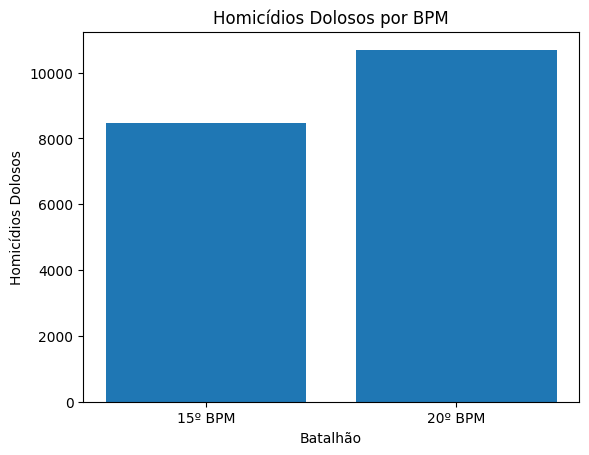

: 

In [ ]:
# Verificar confiabilidade da média
print(f'2. Média: {media:.2f}')
print(f'5. Mediana: {q2:.2f}')
print(f'5. Delta Media/Mediana: {delta:.2f}')
print(f'5. Desvio padrão: {desvio:.2f}')
print(f'5. Coeficiente de variação: {cv*100:.2f}%')

plt.bar(df_grafico['NM_BPM'], df_grafico['hom_doloso'])
plt.xticks(rotation=0)
plt.xlabel('Batalhão')
plt.ylabel('Homicídios Dolosos')
plt.title('Homicídios Dolosos por BPM')
plt.show()